<a href="https://colab.research.google.com/github/SS-Actinium/elevate_labs_task5/blob/main/Int_Elevate_Lab_5_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Task 5
1. Train a Decision Tree Classifier and visualize the tree.
2. Analyze overfitting and control tree depth.
3. Train a Random Forest and compare accuracy.
4. Interpret feature importances.
5. Evaluate using cross-validation.

1. Train a Decision Tree Classifier and visualize the tree.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split , cross_val_score
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier

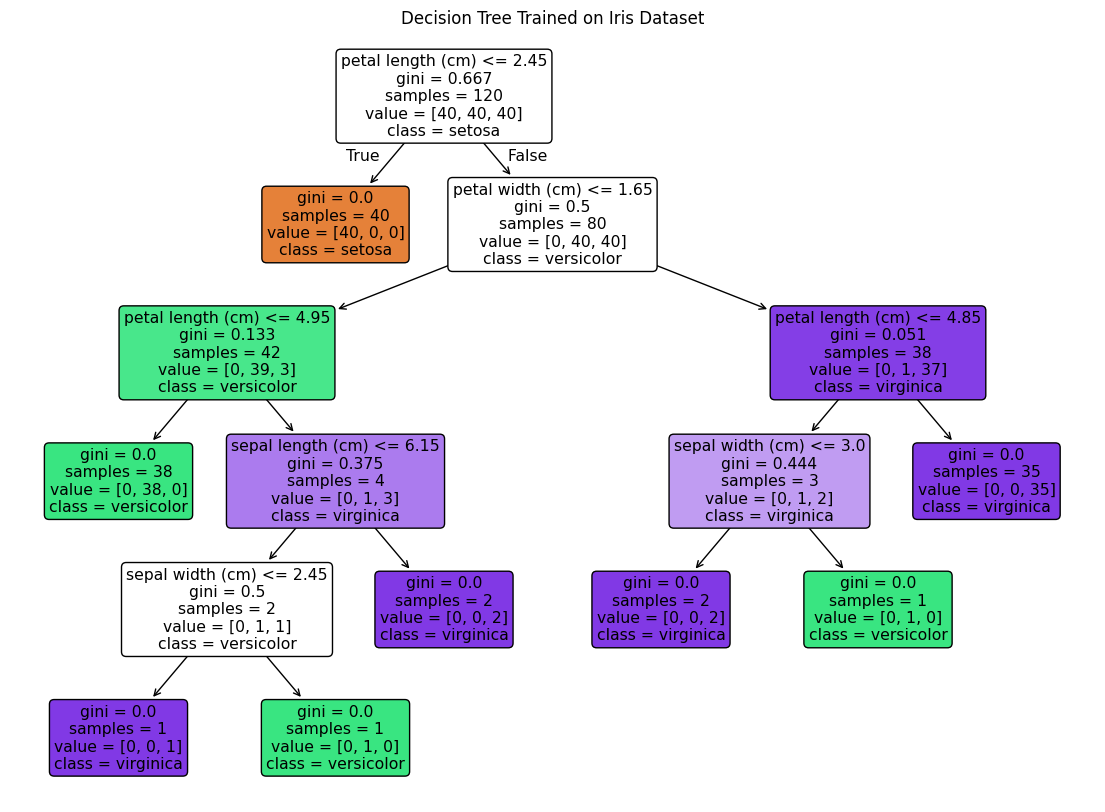

In [ ]:
# Load dataset
iris = load_iris()
X = pd.DataFrame(iris.data, columns=iris.feature_names)
y = iris.target

# Split into 80% Training and 20% Testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 1. Initialize and train the Decision Tree
dt_classifier = DecisionTreeClassifier(random_state=42)
dt_classifier.fit(X_train, y_train)

# 2. Visualize the tree
plt.figure(figsize=(14, 10))
plot_tree(
    dt_classifier,
    feature_names=iris.feature_names,
    class_names=iris.target_names,
    filled=True,
    rounded=True,
)
plt.title("Decision Tree Trained on Iris Dataset")
plt.show()

2. Analyze overfitting and control tree depth.

In [ ]:
depths = [1, 2, 3, 4, None]
print("--- Overfitting & Tree Depth Analysis ---")
for depth in depths:
    model = DecisionTreeClassifier(max_depth=depth, random_state=42)
    model.fit(X_train, y_train)

    train_acc = accuracy_score(y_train, model.predict(X_train))
    test_acc = accuracy_score(y_test, model.predict(X_test))

    depth_label = str(depth) if depth is not None else "Unlimited (Full Tree)"
    print(
        f"Max Depth: {depth_label:<22} | Train Accuracy: {train_acc:.4f} | Test Accuracy: {test_acc:.4f}"
    )

pruned_dt = DecisionTreeClassifier(max_depth=3, random_state=42)
pruned_dt.fit(X_train, y_train)

--- Overfitting & Tree Depth Analysis ---
Max Depth: 1                      | Train Accuracy: 0.6667 | Test Accuracy: 0.6667
Max Depth: 2                      | Train Accuracy: 0.9667 | Test Accuracy: 0.9333
Max Depth: 3                      | Train Accuracy: 0.9833 | Test Accuracy: 0.9667
Max Depth: 4                      | Train Accuracy: 0.9917 | Test Accuracy: 0.9333
Max Depth: Unlimited (Full Tree)  | Train Accuracy: 1.0000 | Test Accuracy: 0.9333


DecisionTreeClassifier(max_depth=3, random_state=42)

3. Train a Random Forest and compare accuracy.

In [ ]:
# 1. Train Random Forest
rf_classifier = RandomForestClassifier(
    n_estimators=100, max_depth=3, random_state=42
)
rf_classifier.fit(X_train, y_train)

# 2. Compare Accuracies
dt_test_acc = accuracy_score(y_test, pruned_dt.predict(X_test))
rf_test_acc = accuracy_score(y_test, rf_classifier.predict(X_test))

print("--- Model Accuracy Comparison ---")
print(f"Decision Tree (max_depth=3) Test Accuracy : {dt_test_acc * 100:.2f}%")
print(f"Random Forest (max_depth=3) Test Accuracy : {rf_test_acc * 100:.2f}%")

--- Model Accuracy Comparison ---
Decision Tree (max_depth=3) Test Accuracy : 96.67%
Random Forest (max_depth=3) Test Accuracy : 96.67%


4. Interpret feature importances.

--- Feature Importances (Random Forest) ---


,Importance Score
petal length (cm),0.440338
petal width (cm),0.439591
sepal length (cm),0.114307
sepal width (cm),0.005764


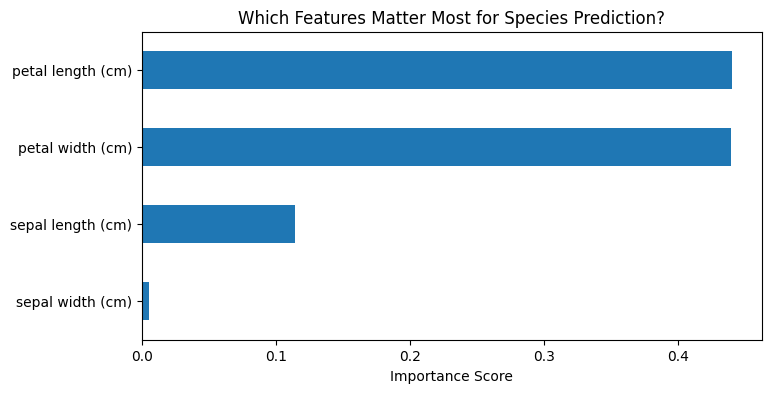

In [ ]:
# Extract feature importances from the Random Forest model
importances = pd.Series(
    rf_classifier.feature_importances_, index=iris.feature_names
)
importances = importances.sort_values(ascending=False)

print("--- Feature Importances (Random Forest) ---")
display(importances.to_frame(name="Importance Score"))

# Visualize with a bar plot
plt.figure(figsize=(8, 4))
importances.plot(kind="barh")
plt.title("Which Features Matter Most for Species Prediction?")
plt.xlabel("Importance Score")
plt.gca().invert_yaxis()
plt.show()

5.

In [ ]:
dt_cv_scores = cross_val_score(pruned_dt, X, y, cv=5, scoring="accuracy")
rf_cv_scores = cross_val_score(rf_classifier, X, y, cv=5, scoring="accuracy")

print("--- 5-Fold Cross-Validation Results ---")
print(
    f"Decision Tree CV Scores : {np.round(dt_cv_scores, 3)} | Mean Accuracy: {dt_cv_scores.mean() * 100:.2f}%"
)
print(
    f"Random Forest CV Scores : {np.round(rf_cv_scores, 3)} | Mean Accuracy: {rf_cv_scores.mean() * 100:.2f}%"
)

--- 5-Fold Cross-Validation Results ---
Decision Tree CV Scores : [0.967 0.967 0.933 1.    1.   ] | Mean Accuracy: 97.33%
Random Forest CV Scores : [0.967 0.967 0.933 0.967 1.   ] | Mean Accuracy: 96.67%
